# Publication-Ready Chess Visualizations

This notebook creates polished visualizations for:
- LinkedIn posts
- portfolio projects
- Kaggle notebooks
- presentation-ready graphics

The focus is on:
- clarity
- storytelling
- visual hierarchy
- communication

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

## Load data

In [2]:
PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import USERNAME

DATA_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / USERNAME
    / f"{USERNAME}_games_clean.csv"
)

PLOTS_DIR = (
    PROJECT_ROOT
    / "plots"
    / USERNAME
)

PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df['result'].unique()

array(['loss', 'win', 'draw'], dtype=object)

In [3]:
df.dtypes

date               datetime64[ns]
year                        int64
month                       int64
weekday                    object
hour                        int64
side                       object
time_class                 object
time_control               object
player_rating               int64
opponent_rating             int64
rating_diff                 int64
result                     object
player_result              object
opponent_result            object
score                     float64
opening                    object
opponent                   object
url                        object
opponent_clean             object
country_code               object
dtype: object

## Global matplotlib style

In [4]:
plt.rcParams.update({

    "figure.figsize": (12, 6),

    "axes.spines.top": False,
    "axes.spines.right": False,

    "axes.titleweight": "bold",

    "axes.titlesize": 18,
    "axes.labelsize": 12,

    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

## Rating progression chart

### Data prep

In [5]:
rapid = (
    df[df["time_class"] == "rapid"]
    .sort_values("date")
)

### Plot

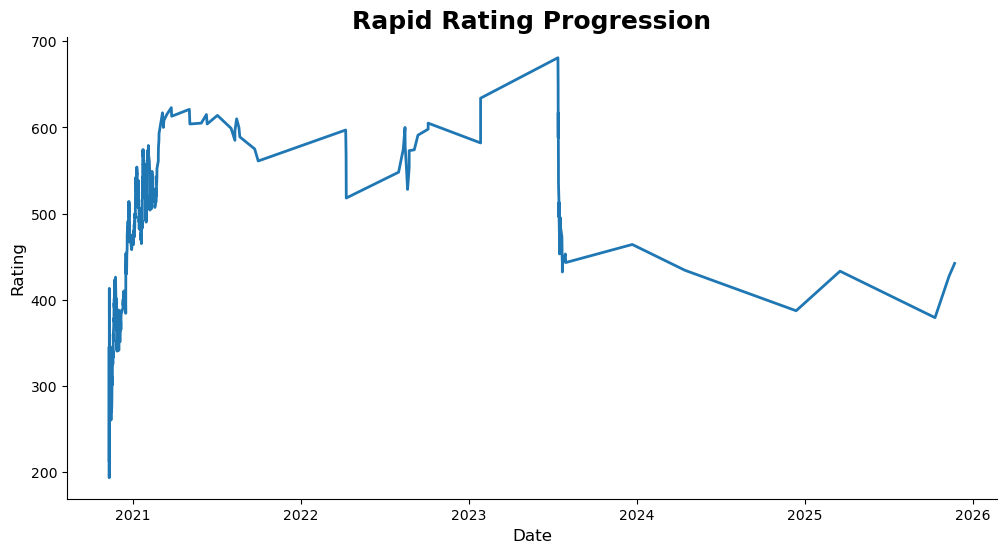

In [6]:
fig, ax = plt.subplots()

ax.plot(
    rapid["date"],
    rapid["player_rating"],
    linewidth=2
)

ax.set_title(
    "Rapid Rating Progression"
)

ax.set_xlabel("Date")
ax.set_ylabel("Rating")

plt.show()

### Export

In [7]:
fig.savefig(
    PLOTS_DIR / "rating_progression.png",
    dpi=300,
    bbox_inches="tight"
)

## Performance by hour

### Aggregate

In [8]:
hourly = (
    df.groupby("hour")
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={
        "url": "games"
    })
)

### Plot

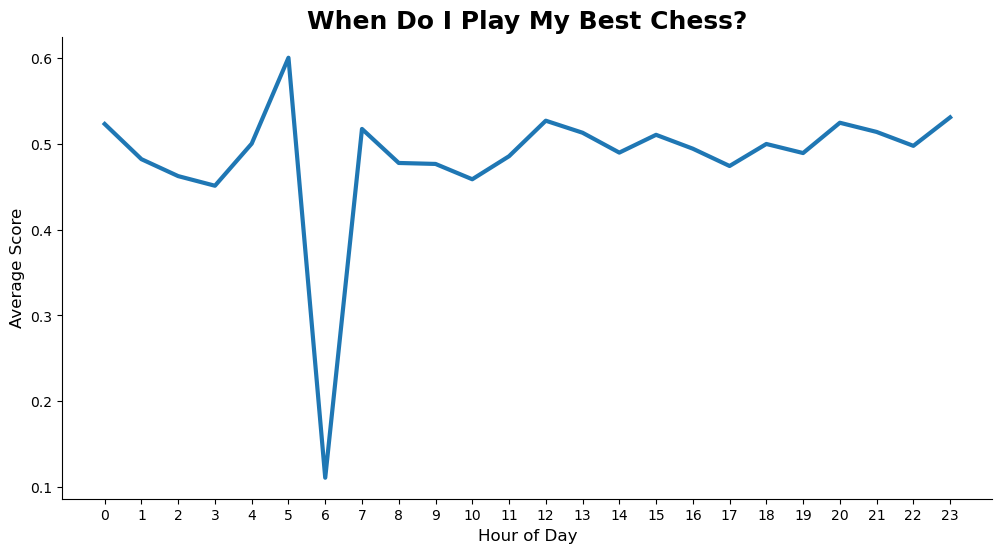

In [9]:
fig, ax = plt.subplots()

ax.plot(
    hourly.index,
    hourly["score"],
    linewidth=3
)

ax.set_title(
    "When Do I Play My Best Chess?"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Score")

ax.set_xticks(range(24))

plt.show()

### Save

In [10]:
fig.savefig(
    PLOTS_DIR / "performance_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

## White vs Black comparison

### Data

In [11]:
side_perf = (
    df.groupby("side")
    .agg({
        "score": "mean",
    })
)

### Plot

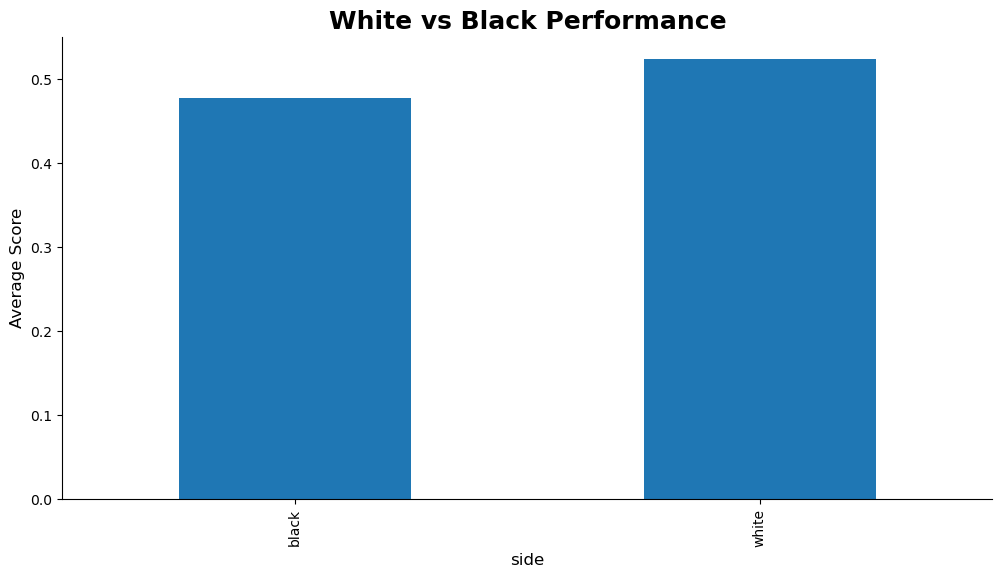

In [12]:
fig, ax = plt.subplots()

side_perf["score"].plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "White vs Black Performance"
)

ax.set_ylabel(
    "Average Score"
)

plt.show()

### Export

In [13]:
fig.savefig(
    PLOTS_DIR / "white_vs_black.png",
    dpi=300,
    bbox_inches="tight"
)

## Opening analysis chart

### Prep

In [14]:
opening_stats = (
    df.groupby("opening")
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={
        "url": "games"
    })
)

opening_stats = (
    opening_stats[
        opening_stats["games"] >= 500
    ]
    .sort_values(
        "score",
        ascending=False
    )
    .head(10)
)

### Plot

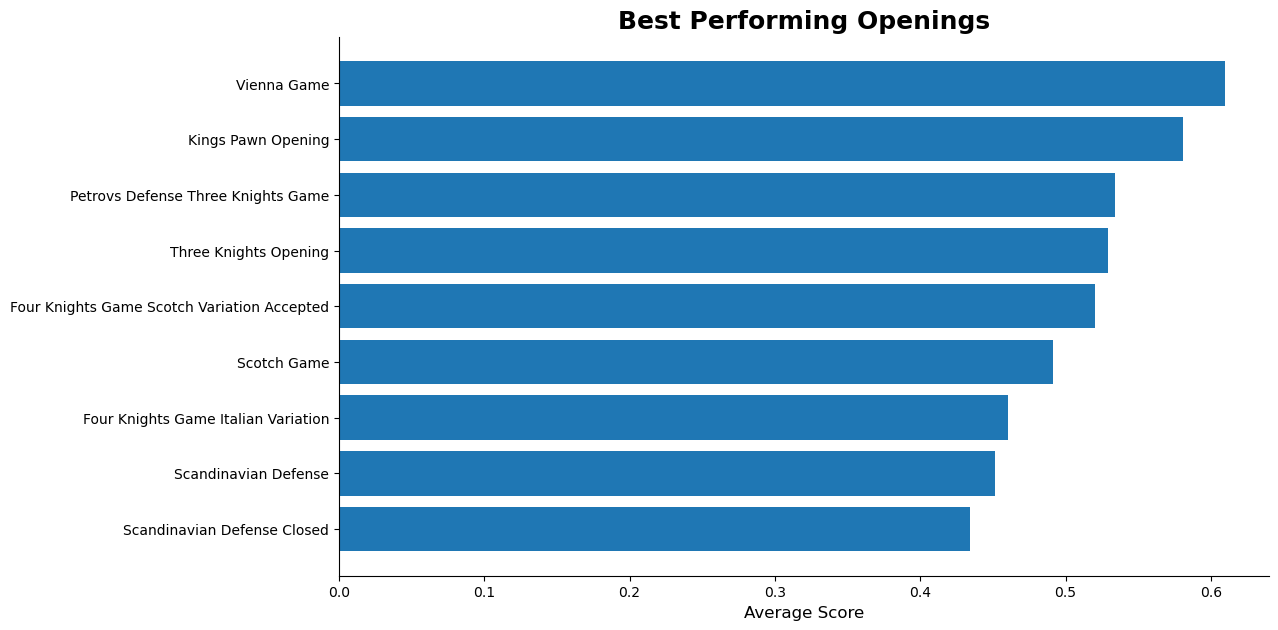

In [15]:
fig, ax = plt.subplots(
    figsize=(12,7)
)

ax.barh(
    opening_stats.index,
    opening_stats["score"]
)

ax.set_title(
    "Best Performing Openings"
)

ax.set_xlabel(
    "Average Score"
)

plt.gca().invert_yaxis()

plt.show()

### Save

In [16]:
fig.savefig(
    PLOTS_DIR / "best_openings.png",
    dpi=300,
    bbox_inches="tight"
)

# Annotations

In [17]:
best_hour = hourly["score"].idxmax()

best_score = hourly["score"].max()

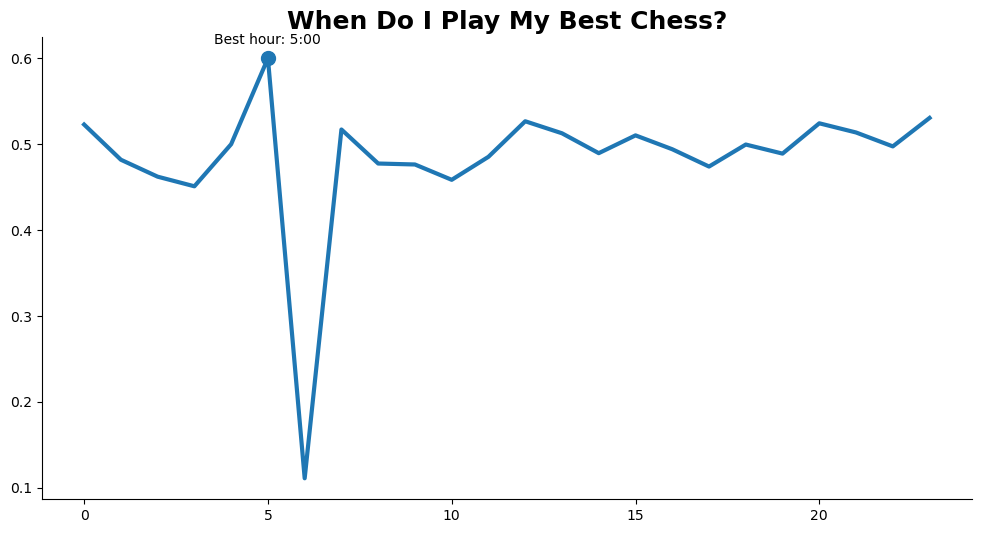

In [18]:
fig, ax = plt.subplots()

ax.plot(
    hourly.index,
    hourly["score"],
    linewidth=3
)

ax.scatter(
    best_hour,
    best_score,
    s=100
)

ax.annotate(
    f"Best hour: {best_hour}:00",
    (best_hour, best_score),
    textcoords="offset points",
    xytext=(0,10),
    ha="center"
)

ax.set_title(
    "When Do I Play My Best Chess?"
)

plt.show()